### Практическая работа №11: Качество кластеризации

Выполнил: Чашин Денис, ЕТ-128

In [19]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.rcParams['figure.figsize'] = (16, 10)

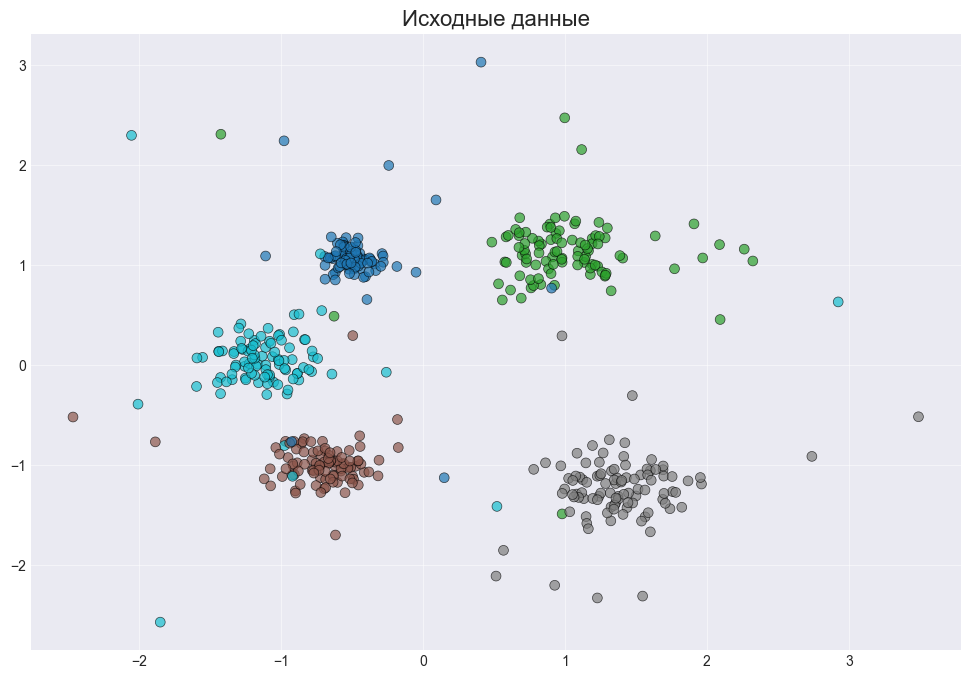

In [20]:
# Создаем набор данных
# Функция добавления шума
def add_noise(data, noise_percentage, noise_magnitude=0.5):
    data_noisy = data.copy()
    n_points = len(data)
    n_noisy = int(n_points * noise_percentage / 100)

    noisy_indices = np.random.choice(n_points, n_noisy, replace=False)

    for idx in noisy_indices:
        noise = np.random.randn(data.shape[1]) * noise_magnitude
        data_noisy[idx] += noise

    return data_noisy, noisy_indices

np.random.seed(25)
X, y_true = make_blobs(n_samples=500,
                       centers=5,
                       cluster_std=[0.7, 1.5, 1.2, 1.5, 1.4],
                       random_state=31)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Визуализируем данные
noise_pct = 10
X_noisy, _ = add_noise(X_scaled, noise_pct, noise_magnitude=1.0)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=y_true, cmap='tab10', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.title('Исходные данные', fontsize=16)
plt.grid(True, alpha=0.5)

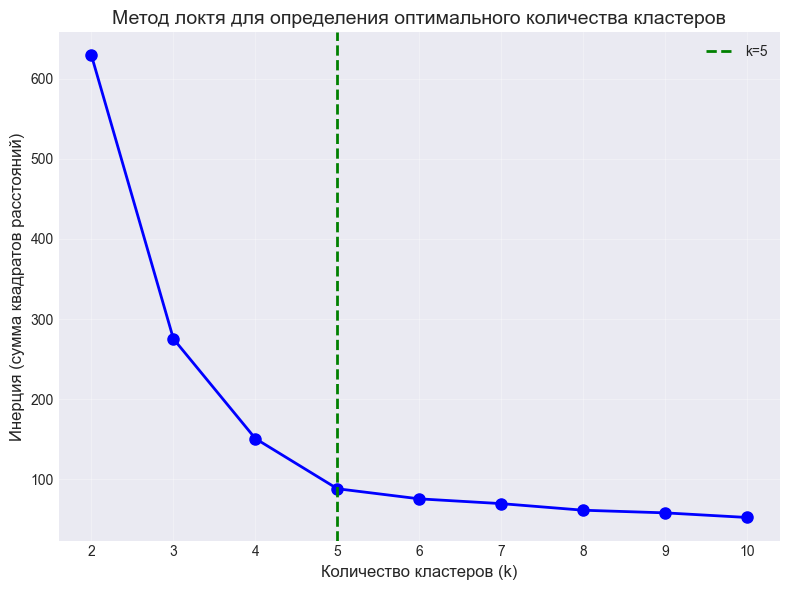

In [23]:
# Метод локтя (ELBOW)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_noisy)
    inertias.append(kmeans.inertia_)

    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_noisy, labels))

# Визуализация метода локтя
plt.figure(figsize=(8, 6))

plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='green', linestyle='--', linewidth=2, label='k=5')

plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
plt.title('Метод локтя для определения оптимального количества кластеров', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(K_range)

plt.tight_layout()
plt.show()

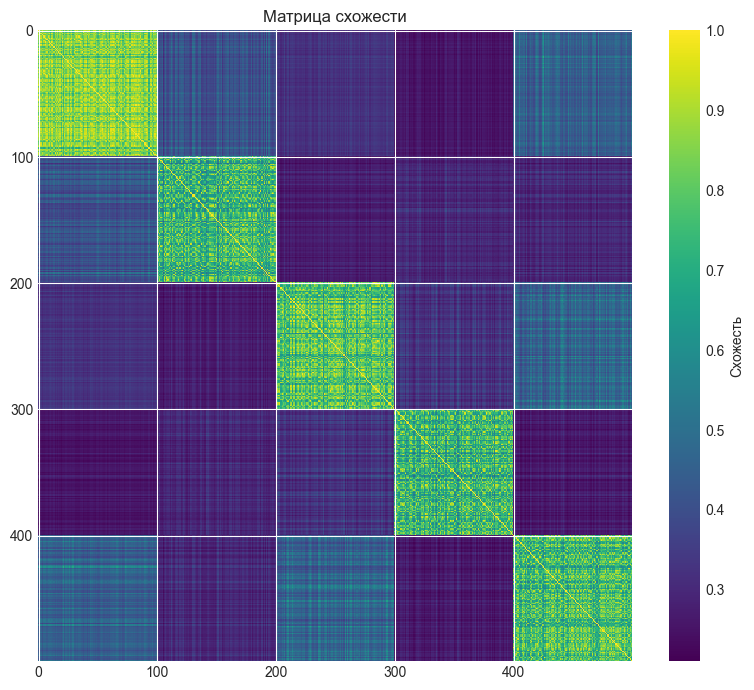

In [25]:
# Матрица схожести
from scipy.spatial.distance import pdist, squareform
import numpy as np
import matplotlib.pyplot as plt

# Сортируем объекты по истинным кластерам для наглядности
sort_idx = np.argsort(y_true)
X_sorted = X_scaled[sort_idx]
y_sorted = y_true[sort_idx]

# Матрица попарных расстояний
distance_matrix_sorted = squareform(pdist(X_sorted, metric='euclidean'))

# Преобразуем расстояния в схожесть
similarity_matrix = 1 / (1 + distance_matrix_sorted)

# Построение тепловой карты
plt.figure(figsize=(8, 7))

im = plt.imshow(
    similarity_matrix,
    cmap='viridis',
    aspect='auto',
    interpolation='nearest'
)

plt.title('Матрица схожести', fontsize=12)
plt.colorbar(im, label='Схожесть')

plt.tight_layout()
plt.show()